In [113]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


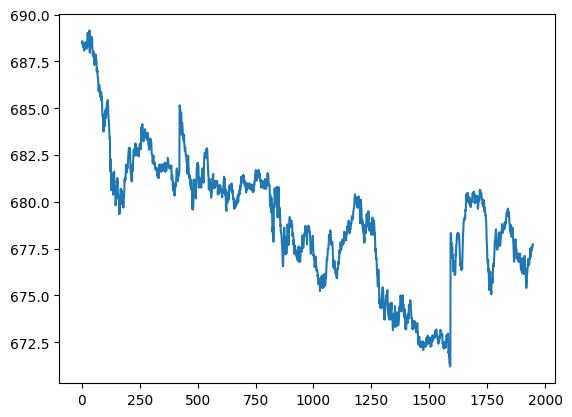

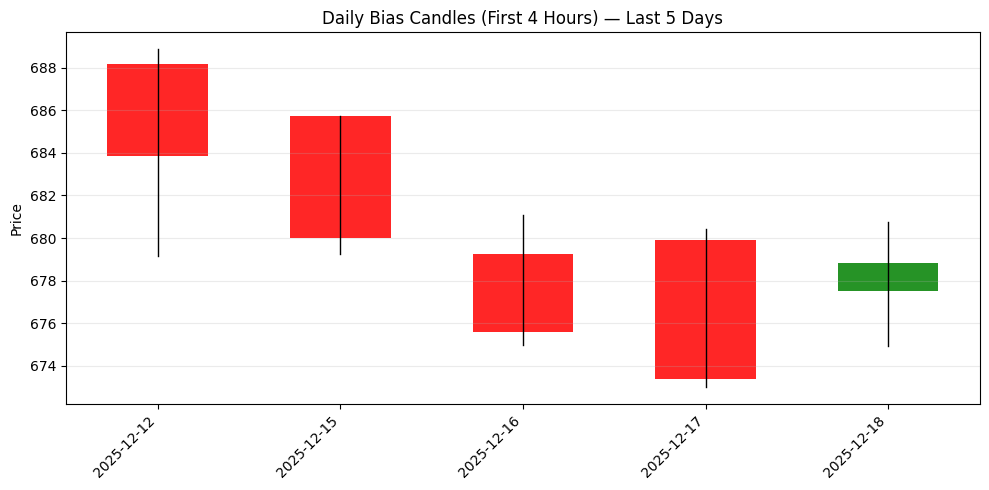

In [120]:
TICKER = 'SPY'
INTERVAL='1m'
BIAS_LEN = 4 * 60
COMPLETE_DAY = 390

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    df['Date'] = pd.to_datetime(df.index.values)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # plot the minutely data
    plt.plot(df['Close'])

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

def daily_bias(df, bias_len=BIAS_LEN):

    df = df.copy()
    df['Day'] = df['Date'].dt.date
    bias_info = df.groupby(('Day'), sort=True).head(bias_len)

    # keep only complete days
    counts = bias_info.groupby('Day').size()
    complete_days = counts[counts == bias_len].index

    daily_bias_df = bias_info[bias_info['Day'].isin(complete_days)].reset_index(drop=True)

    return daily_bias_df


def plot_daily_bias(daily_bias_df):
    df = daily_bias_df.copy()

    # 1) Build ONE 4-hour OHLC candle per Day
    daily_ohlc = (
        df.groupby("Day", sort=True)
          .apply(lambda g: {
              "Open":  g["Open"].iloc[0],
              "Close": g["Close"].iloc[-1],
              "High":  g["High"].max(),
              "Low":   g["Low"].min()
          }
          , include_groups=False)
    )

    daily_ohlc = daily_ohlc.apply(pd.Series).reset_index()

    # 2) Plot as "box + whisker" candlesticks
    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(daily_ohlc))
    width = 0.55  # body width

    for i, row in daily_ohlc.iterrows():
        o, c, h, l = row["Open"], row["Close"], row["High"], row["Low"]

        # Wick (low -> high)
        ax.plot([x[i], x[i]], [l, h], linewidth=1, color="black")

        # Body (open -> close)
        body_bottom = min(o, c)
        body_height = abs(c - o)

        color = "green" if c >= o else "red"

        ax.bar(
            x[i],
            body_height if body_height != 0 else 0.0001,  # tiny body if doji
            bottom=body_bottom,
            width=width,
            color=color,
            alpha=0.85
        )

    # X labels as dates
    ax.set_xticks(x)
    ax.set_xticklabels([str(d) for d in daily_ohlc["Day"]], rotation=45, ha="right")

    ax.set_title(f"Daily Bias Candles (First {BIAS_LEN//60} Hours) — Last {len(daily_ohlc)} Days")
    ax.set_ylabel("Price")
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    return daily_ohlc  # handy to inspect the computed candles

def compute_daily_bias_flags(daily_bias_df):
    bias_flags = (
        daily_bias_df
        .groupby("Day")
        .apply(
            lambda g: int(g["Close"].iloc[-1] > g["Open"].iloc[0]),
            include_groups=False
        )
        .rename("Bias")
        .reset_index()
    )
    return bias_flags

def test_daily_bias(df, bias_len=BIAS_LEN, complete_day=COMPLETE_DAY):

    df = df.copy()
    df['Day'] = df['Date'].dt.date

    # 🔒 drop the current (most recent) trading day
    last_day = df['Day'].max()
    df = df[df['Day'] < last_day]

    bias_info = df.groupby('Day', sort=True).tail(complete_day - bias_len)

    # keep only complete days
    counts = bias_info.groupby('Day').size()
    complete_days = counts[counts == (complete_day - bias_len)].index

    remaining_data = (
        bias_info[bias_info['Day'].isin(complete_days)]
        .reset_index(drop=True)
    )

    return remaining_data

def main():
    df = get_data()
    daily_bias_df = daily_bias(df)
    plot_daily_bias(daily_bias_df)
    bias_flags = compute_daily_bias_flags(daily_bias_df)

    remaining_data = test_daily_bias(df)

    remaining_data = remaining_data.merge(
        bias_flags,
        on="Day",
        how="left"
    )
    
    return df, daily_bias_df, bias_flags, remaining_data

df, daily_bias_df, bias_flags, remaining_data = main()

In [115]:
df

Price,Close,High,Low,Open,Volume,Date
0,688.799988,688.839905,688.719971,688.750000,0,2025-12-11 20:24:00
1,688.679993,688.825012,688.650024,688.789978,151094,2025-12-11 20:25:00
2,688.534973,688.690002,688.520020,688.690002,210653,2025-12-11 20:26:00
3,688.479980,688.539978,688.424988,688.534973,242861,2025-12-11 20:27:00
4,688.575012,688.609924,688.434998,688.479980,127752,2025-12-11 20:28:00
...,...,...,...,...,...,...
1943,677.570007,677.575012,677.369995,677.400024,144343,2025-12-18 20:19:00
1944,677.400024,677.669983,677.333984,677.575623,199564,2025-12-18 20:20:00
1945,677.419983,677.445007,677.229980,677.400024,192459,2025-12-18 20:21:00
1946,677.575012,677.619995,677.320007,677.419983,248652,2025-12-18 20:22:00


In [116]:
daily_bias_df

Price,Close,High,Low,Open,Volume,Date,Day
0,687.960022,688.250000,687.880005,688.169983,1963046,2025-12-12 14:30:00,2025-12-12
1,688.469971,688.559998,687.700012,687.960022,476482,2025-12-12 14:31:00,2025-12-12
2,688.190002,688.479980,688.000000,688.479980,336536,2025-12-12 14:32:00,2025-12-12
3,688.554993,688.614990,688.140015,688.169983,190859,2025-12-12 14:33:00,2025-12-12
4,688.414978,688.684998,688.330017,688.559998,265628,2025-12-12 14:34:00,2025-12-12
...,...,...,...,...,...,...,...
1195,678.669983,678.929993,678.664978,678.900024,99979,2025-12-18 18:25:00,2025-12-18
1196,678.850098,678.960022,678.679993,678.679993,166712,2025-12-18 18:26:00,2025-12-18
1197,678.900024,678.950012,678.789978,678.859985,77875,2025-12-18 18:27:00,2025-12-18
1198,678.859985,679.090027,678.789978,678.900024,113673,2025-12-18 18:28:00,2025-12-18


In [121]:
remaining_data

,Close,High,Low,Open,Volume,Date,Day,Bias
0,683.739990,683.830017,683.565002,683.570007,123309,2025-12-12 18:28:00,2025-12-12,0
1,683.880005,683.880005,683.690308,683.760010,54977,2025-12-12 18:29:00,2025-12-12,0
2,683.690002,683.900024,683.669983,683.880005,81788,2025-12-12 18:30:00,2025-12-12,0
3,683.650024,683.753174,683.520020,683.690002,83813,2025-12-12 18:31:00,2025-12-12,0
4,683.489990,683.700012,683.479980,683.659973,115158,2025-12-12 18:32:00,2025-12-12,0
...,...,...,...,...,...,...,...,...
595,671.385010,671.789978,671.260010,671.789978,892767,2025-12-17 20:55:00,2025-12-17,0
596,671.320007,671.500000,671.299988,671.390015,767390,2025-12-17 20:56:00,2025-12-17,0
597,671.289978,671.599976,671.270020,671.309998,924299,2025-12-17 20:57:00,2025-12-17,0
598,671.205017,671.440979,671.200012,671.294983,1285457,2025-12-17 20:58:00,2025-12-17,0


In [118]:
bias_flags

,Day,Bias
0,2025-12-12,0
1,2025-12-15,0
2,2025-12-16,0
3,2025-12-17,0
4,2025-12-18,1
